In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cohort_index_dataset.csv to cohort_index_dataset.csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Day_Name,First_Purchase_Date,Cohort_Month,Order_Month,Revenue,Cohort_Index
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,Tuesday,2009-12-01 07:45:00,2009-12,2009-12,83.4,1.0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,Tuesday,2009-12-01 07:45:00,2009-12,2009-12,81.0,1.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,Tuesday,2009-12-01 07:45:00,2009-12,2009-12,81.0,1.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,Tuesday,2009-12-01 07:45:00,2009-12,2009-12,100.8,1.0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,Tuesday,2009-12-01 07:45:00,2009-12,2009-12,30.0,1.0


In [4]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country', 'Year', 'Month', 'Day', 'Day_Name',
       'First_Purchase_Date', 'Cohort_Month', 'Order_Month', 'Revenue',
       'Cohort_Index'],
      dtype='object')

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [6]:
df['Revenue'] = df['Quantity'] * df['Price']

kpi calculations

In [7]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 18972492.18799999


In [8]:
total_customers = df['Customer_ID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 5924


In [9]:
total_orders = df['Invoice'].nunique()
print("Total Orders:", total_orders)

Total Orders: 52961


In [10]:
aov = total_revenue / total_orders
print("Average Order Value:", aov)

Average Order Value: 358.23515771983136


In [11]:
revenue_per_customer = total_revenue / total_customers
print("Revenue per Customer:", revenue_per_customer)

Revenue per Customer: 3202.6489176232258


In [12]:
purchase_freq = total_orders / total_customers
print("Purchase Frequency:", purchase_freq)

Purchase Frequency: 8.940074274139095


In [13]:
repeat_customers = df[df.duplicated('Customer_ID')]['Customer_ID'].nunique()

retention_rate = repeat_customers / total_customers
print("Retention Rate:", retention_rate)

Retention Rate: 0.9753544902093181


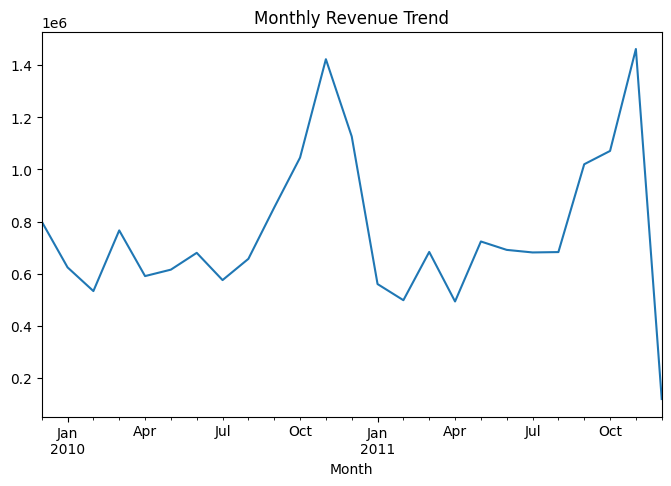

In [14]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue.plot(figsize=(8,5), title="Monthly Revenue Trend")
plt.show()

In [15]:
top_customers = df.groupby('Customer_ID')['Revenue'].sum().sort_values(ascending=False).head(5)
print(top_customers)

Customer_ID
18102.0    586729.68
14646.0    511614.05
14156.0    296564.69
14911.0    263946.56
17450.0    233579.39
Name: Revenue, dtype: float64


In [16]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5)
print(top_products)

Description
REGENCY CAKESTAND 3 TIER              322643.15
DOTCOM POSTAGE                        304979.93
WHITE HANGING HEART T-LIGHT HOLDER    255777.96
JUMBO BAG RED RETROSPOT               147803.47
PARTY BUNTING                         147361.56
Name: Revenue, dtype: float64
